
# Sentiment Analysis on Book Reviews using RNN, LSTM, and LSTM + Word2Vec

This notebook is adapted for a book review dataset with the columns:

- `rating`
- `reviewText`
- `summary`

The target labels are created from `rating`:
- 1–2 → **negative**
- 3 → **neutral**
- 4–5 → **positive**

The third model uses **LSTM + Word2Vec** and includes a few accuracy-focused upgrades:
- combined text from `summary + reviewText`
- class weights for imbalance
- stronger LSTM architecture
- early stopping and learning-rate reduction
- train/validation/test split without leakage



## 1) Install dependencies


In [74]:
!pip -q install gensim wordcloud gradio nltk seaborn


## 2) Imports and setup


In [75]:

import os
import re
import json
import pickle
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout,
    SpatialDropout1D, Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

import gensim
from gensim.models import Word2Vec

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



## 3) Google Drive mount



In [76]:

try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted.")
except Exception:
    print("Not running in Google Colab, or Drive mount is unavailable. Skipping.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.



## 4) Load the book review dataset

Set `CSV_PATH` to your file location.

Expected columns:
- `rating`
- `reviewText`
- `summary`


In [77]:

CSV_PATH = "/content/drive/MyDrive/AI_ML/CourseWork/NLP/Book_review.csv"   # change this to your actual file path

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"Could not find dataset at: {CSV_PATH}\n"
        "Please update CSV_PATH to the correct location of your book review CSV file."
    )

df = pd.read_csv(CSV_PATH)
print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Raw shape: (12000, 4)
Columns: ['Unnamed: 0', 'rating', 'reviewText', 'summary']


,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,4,5,"This isn't the kind of book I normally read, a...",Great Story!



## 5) Clean and prepare the dataset


In [78]:

# Keep only the columns we need, but do it safely even if extra columns exist
required_cols = ["rating", "reviewText", "summary"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[required_cols].copy()

# Standardize data types and missing values
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["reviewText"] = df["reviewText"].fillna("").astype(str)
df["summary"] = df["summary"].fillna("").astype(str)

# Drop rows with missing rating
df = df.dropna(subset=["rating"]).reset_index(drop=True)

def rating_to_sentiment(r):
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(rating_to_sentiment)

# Combine summary + reviewText for better context
df["text"] = (df["summary"].str.strip() + " " + df["reviewText"].str.strip()).str.strip()
df["text"] = df["text"].replace("", np.nan)
df = df.dropna(subset=["text"]).reset_index(drop=True)

# Remove duplicates
df = df.drop_duplicates(subset=["text", "sentiment"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
print(df[["rating", "sentiment", "summary", "reviewText"]].head(3).to_string(index=False))


Cleaned shape: (12000, 5)
 rating sentiment                         summary                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             


## 6) Exploratory data analysis


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   rating      12000 non-null  int64 
 1   reviewText  12000 non-null  object
 2   summary     12000 non-null  object
 3   sentiment   12000 non-null  object
 4   text        12000 non-null  object
dtypes: int64(1), object(4)
memory usage: 468.9+ KB
None

Missing values:
 rating        0
reviewText    0
summary       0
sentiment     0
text          0
dtype: int64

Sentiment distribution:
 sentiment
positive    6000
negative    4000
neutral     2000
Name: count, dtype: int64


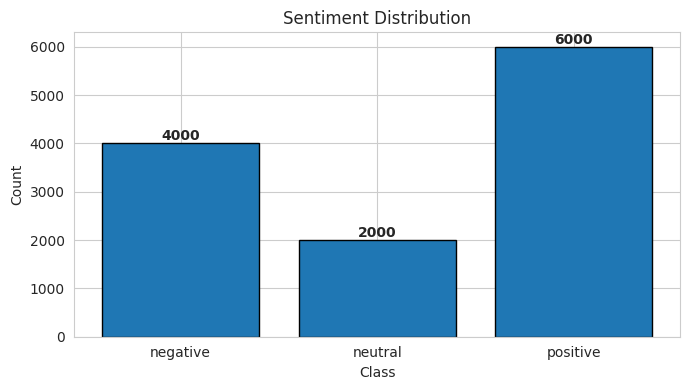

In [79]:

print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nSentiment distribution:\n", df["sentiment"].value_counts())

label_order = ["negative", "neutral", "positive"]
count_series = df["sentiment"].value_counts().reindex(label_order)

plt.figure(figsize=(7, 4))
bars = plt.bar(count_series.index, count_series.values, edgecolor="black")
plt.title("Sentiment Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
for bar, val in zip(bars, count_series.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(val),
             ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()


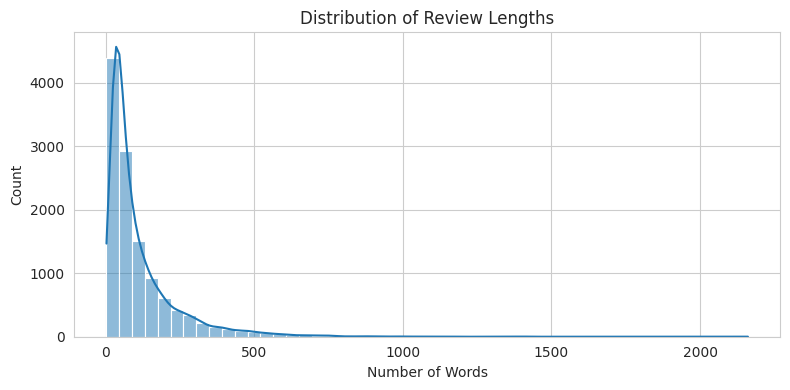

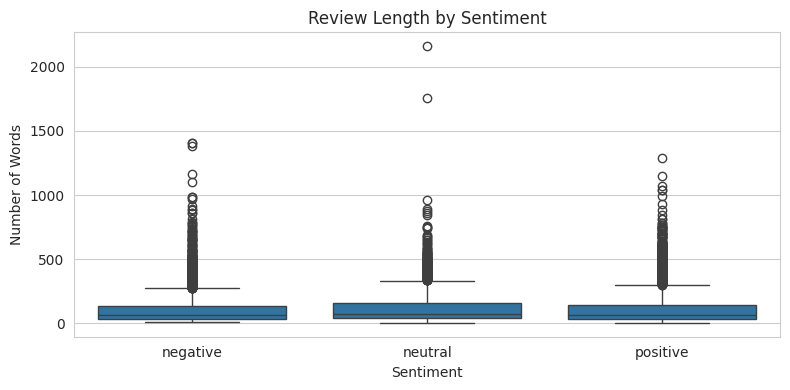

In [80]:

# Review length analysis
df["text_len"] = df["text"].str.split().apply(len)

plt.figure(figsize=(8, 4))
sns.histplot(df["text_len"], bins=50, kde=True)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="sentiment", y="text_len", order=label_order)
plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()



## 7) Text preprocessing
For the Word2Vec model, we keep preprocessing moderate so the embedding model can still learn useful word relationships.


In [81]:

STOP_WORDS = set(stopwords.words("english"))
# Keep negation words, because they matter a lot for sentiment
STOP_WORDS = STOP_WORDS - {"no", "nor", "not", "never"}
lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "can't": "cannot", "couldn't": "could not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "it's": "it is", "i'm": "i am", "i've": "i have", "i'll": "i will",
    "he's": "he is", "she's": "she is", "they're": "they are",
    "we're": "we are", "you're": "you are", "that's": "that is",
    "there's": "there is", "what's": "what is", "who's": "who is",
    "let's": "let us", "n't": " not"
}

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    return text

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)

    text = text.lower()
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = expand_contractions(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for word in text.split():
        if word in STOP_WORDS:
            continue
        lemma = lemmatizer.lemmatize(word)
        if lemma:
            tokens.append(lemma)

    return " ".join(tokens)

df["cleaned_text"] = df["text"].apply(clean_text)
df[["text", "cleaned_text", "sentiment"]].head()


,text,cleaned_text,sentiment
0,50 + years ago... This book was the very first...,year ago book first bookmobile book bought sch...,positive
1,Boring! Boring! Boring! When I read the descri...,boring boring boring read description book cou...,negative
2,Wiggleliscious/new toy ready/!! I just had to ...,wiggleliscious new toy ready edit review book ...,positive
3,Very good read. I don't normally buy 'mystery'...,good read not normally buy 'mystery' novel not...,positive
4,Great Story! This isn't the kind of book I nor...,great story not kind book normally read althou...,positive


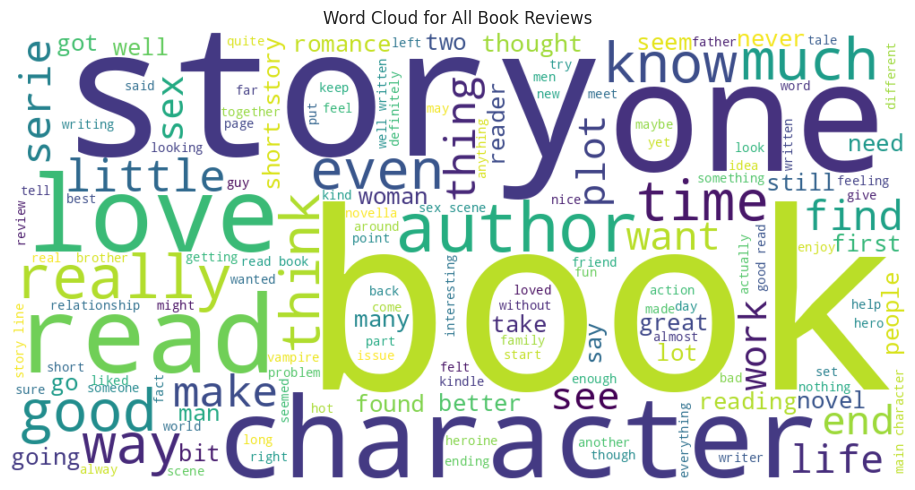

In [82]:

# Optional word cloud
try:
    from wordcloud import WordCloud

    all_text = " ".join(df["cleaned_text"].tolist())
    wc = WordCloud(width=1000, height=500, background_color="white", max_words=150).generate(all_text)

    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud for All Book Reviews")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("WordCloud skipped:", e)



## 8) Train/test split, tokenization, and padding


In [86]:

label_enc = LabelEncoder()
df["label"] = label_enc.fit_transform(df["sentiment"])
print("Label mapping:", dict(zip(label_enc.classes_, label_enc.transform(label_enc.classes_))))

X = df["cleaned_text"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Create a validation split from the training data only
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.10, random_state=42, stratify=y_train
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

NUM_WORDS = 20000
tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_seq = tokenizer.texts_to_sequences(X_train)
val_seq   = tokenizer.texts_to_sequences(X_val)
test_seq  = tokenizer.texts_to_sequences(X_test)

lengths = [len(s) for s in train_seq if len(s) > 0]
MAX_LEN = int(np.percentile(lengths, 95)) if lengths else 100
MAX_LEN = max(20, min(MAX_LEN, 300))

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad   = pad_sequences(test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

VOCAB_SIZE = min(NUM_WORDS, len(tokenizer.word_index) + 1)

print("VOCAB_SIZE:", VOCAB_SIZE)
print("MAX_LEN:", MAX_LEN)
print("Train padded shape:", X_train_pad.shape)
print("Val padded shape:", X_val_pad.shape)
print("Test padded shape:", X_test_pad.shape)


Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Train: 8640 | Val: 960 | Test: 2400
VOCAB_SIZE: 20000
MAX_LEN: 188
Train padded shape: (8640, 188)
Val padded shape: (960, 188)
Test padded shape: (2400, 188)



## 9) pre - trained word2vec model:

The Word2Vec model is trained only on the training texts to avoid leakage.


In [84]:
W2V_DIM = 100
print("Training Word2Vec...")
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=W2V_DIM,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10
)
print("Word2Vec training complete.")
print("Vocabulary size in Word2Vec:", len(w2v_model.wv))

embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
covered = 0

for word, idx in tokenizer.word_index.items():
    if idx < VOCAB_SIZE and word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        covered += 1

coverage = covered / max(1, VOCAB_SIZE - 1) * 100
print(f"Word2Vec coverage: {covered} words ({coverage:.2f}%)")
print("Embedding matrix shape:", embedding_matrix.shape)

Training Word2Vec...
Word2Vec training complete.
Vocabulary size in Word2Vec: 14354
Word2Vec coverage: 14336 words (57.03%)
Embedding matrix shape: (25140, 100)


In [87]:

embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
covered = 0

for word, idx in tokenizer.word_index.items():
    if idx < VOCAB_SIZE and word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        covered += 1

coverage = covered / max(1, VOCAB_SIZE - 1) * 100
print(f"Word2Vec coverage: {covered} words ({coverage:.2f}%)")
print("Embedding matrix shape:", embedding_matrix.shape)


Word2Vec coverage: 14336 words (71.68%)
Embedding matrix shape: (20000, 100)



## 10) Class weights for imbalance handling


In [89]:
classes = np.unique(y_train)
class_weights_arr = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}
class_weights

{0: 1.0, 1: 2.0, 2: 0.6666666666666666}


## 11) Model definitions
We keep three models for comparison:

1. **Simple RNN**
2. **LSTM**
3. **LSTM + Word2Vec** (improved model)


In [91]:

EMBED_DIM = 128
NUM_CLASSES = len(label_enc.classes_)

def build_simple_rnn_model():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SpatialDropout1D(0.2),
        SimpleRNN(64),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation="softmax")
    ], name="SimpleRNN")
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

def build_lstm_model():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SpatialDropout1D(0.2),
        LSTM(64, dropout=0.2, recurrent_dropout=0.2),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation="softmax")
    ], name="LSTM_Trainable")
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

def build_w2v_lstm_model():
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=W2V_DIM,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=True
        ),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation="softmax")
    ], name="LSTM_Word2Vec")
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model3 = build_w2v_lstm_model()

model1 = build_simple_rnn_model()
model2 = build_lstm_model()
model3 = build_w2v_lstm_model()

model1.build(input_shape=(None, MAX_LEN))
model2.build(input_shape=(None, MAX_LEN))
model3.build(input_shape=(None, MAX_LEN))

model1.summary()


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_28 (Embedding)        │ (None, 188, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_28            │ (None, 188, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,576,707 (9.83 MB)

 Trainable params: 2,576,707 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

In [92]:

model2.summary()


Model: "LSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_29 (Embedding)        │ (None, 188, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_29            │ (None, 188, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,613,763 (9.97 MB)

 Trainable params: 2,613,763 (9.97 MB)

 Non-trainable params: 0 (0.00 B)

In [93]:

model3.summary()


Model: "LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_30 (Embedding)        │ (None, 188, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_30            │ (None, 188, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_14                │ (None, 128)            │        84,480 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,093,187 (7.98 MB)

 Trainable params: 2,093,059 (7.98 MB)

 Non-trainable params: 128 (512.00 B)


## 12) Training callbacks


In [94]:

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

checkpoint_path = "/content/best_lstm_word2vec.keras"
checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

callbacks = [early_stop, reduce_lr]



## 13) Train the models
For a faster first run, you can reduce `EPOCHS` to 5.  
For better accuracy, keep it at 8–12 and let early stopping choose the best epoch.


In [95]:

EPOCHS = 12
BATCH_SIZE = 32

history1 = model1.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/12
270/270 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.3324 - loss: 1.1096 - val_accuracy: 0.3010 - val_loss: 1.1024 - learning_rate: 0.0010
Epoch 2/12
270/270 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.3453 - loss: 1.0980 - val_accuracy: 0.4812 - val_loss: 1.0890 - learning_rate: 0.0010
Epoch 3/12
270/270 ━━━━━━━━━━━━━━━━━━━━ 25s 74ms/step - accuracy: 0.3503 - loss: 1.0787 - val_accuracy: 0.4875 - val_loss: 1.0914 - learning_rate: 0.0010
Epoch 4/12
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4250 - loss: 1.0404
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
270/270 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.3766 - loss: 1.0528 - val_accuracy: 0.1906 - val_loss: 1.1166 - learning_rate: 0.0010
Epoch 5/12
270/270 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.3374 - loss: 1.0383 - val_accuracy: 0.3469 - val_loss: 1.1057 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best e

In [96]:

history2 = model2.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/12
270/270 ━━━━━━━━━━━━━━━━━━━━ 43s 152ms/step - accuracy: 0.3219 - loss: 1.0998 - val_accuracy: 0.3302 - val_loss: 1.0919 - learning_rate: 0.0010
Epoch 2/12
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.3429 - loss: 1.1013
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
270/270 ━━━━━━━━━━━━━━━━━━━━ 40s 147ms/step - accuracy: 0.3454 - loss: 1.0969 - val_accuracy: 0.3344 - val_loss: 1.1009 - learning_rate: 0.0010
Epoch 3/12
270/270 ━━━━━━━━━━━━━━━━━━━━ 39s 143ms/step - accuracy: 0.3853 - loss: 1.0791 - val_accuracy: 0.3385 - val_loss: 1.1049 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [101]:
history3 = model3.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks + [checkpoint],
    verbose=1
)

Epoch 1/12
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7525 - loss: 0.6498
Epoch 1: val_accuracy did not improve from 0.68854
270/270 ━━━━━━━━━━━━━━━━━━━━ 67s 248ms/step - accuracy: 0.7402 - loss: 0.6644 - val_accuracy: 0.6844 - val_loss: 0.7099 - learning_rate: 5.0000e-04
Epoch 2/12
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.7602 - loss: 0.6285
Epoch 2: val_accuracy improved from 0.68854 to 0.72292, saving model to /content/best_lstm_word2vec.keras

Epoch 2: finished saving model to /content/best_lstm_word2vec.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 69s 254ms/step - accuracy: 0.7579 - loss: 0.6360 - val_accuracy: 0.7229 - val_loss: 0.6455 - learning_rate: 5.0000e-04
Epoch 3/12
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.7861 - loss: 0.5816
Epoch 3: val_accuracy improved from 0.72292 to 0.73333, saving model to /content/best_lstm_word2vec.keras

Epoch 3: finished saving model to /content/best_lstm_word2vec.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 67s 249ms/


## 14) Training curves


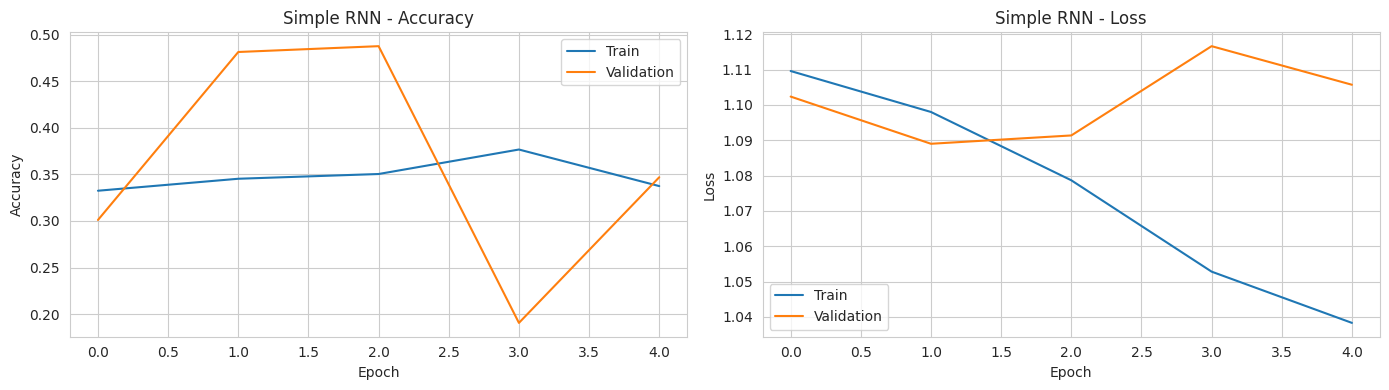

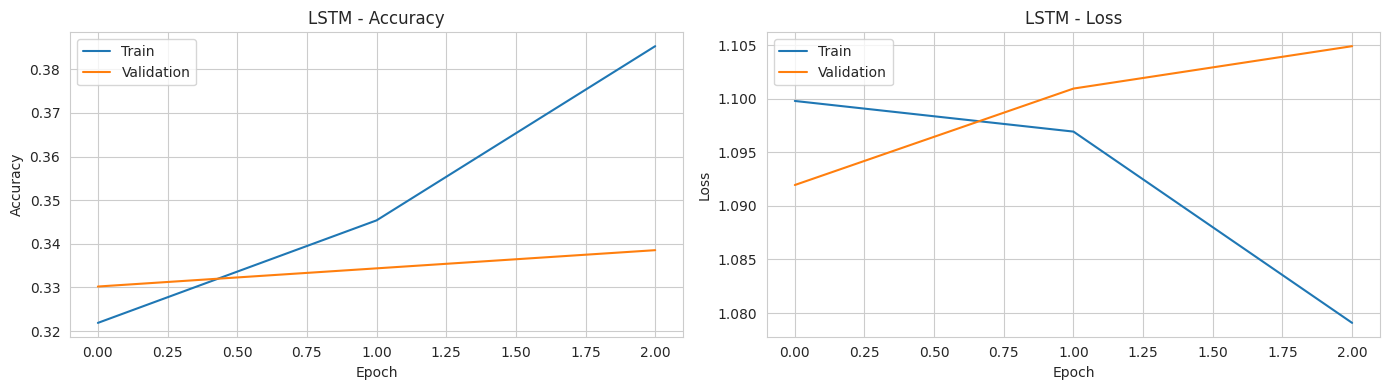

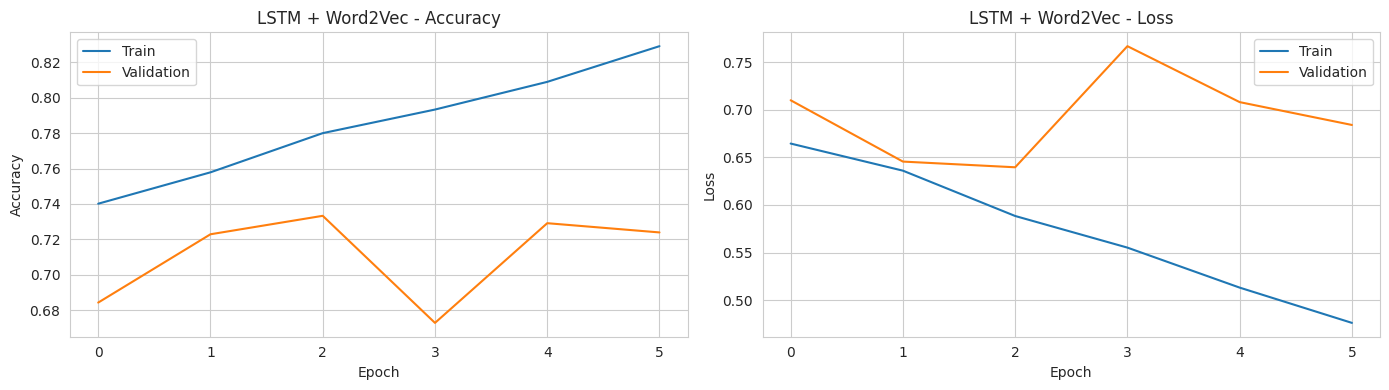

In [102]:

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history.history["accuracy"], label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Validation")
    axes[0].set_title(f"{title} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="Train")
    axes[1].plot(history.history["val_loss"], label="Validation")
    axes[1].set_title(f"{title} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history1, "Simple RNN")
plot_history(history2, "LSTM")
plot_history(history3, "LSTM + Word2Vec")


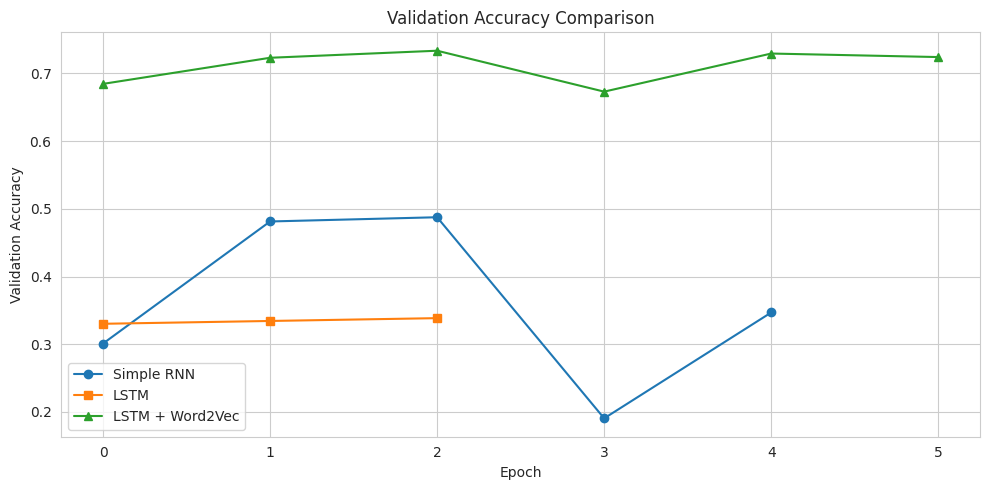

In [103]:

plt.figure(figsize=(10, 5))
plt.plot(history1.history["val_accuracy"], marker="o", label="Simple RNN")
plt.plot(history2.history["val_accuracy"], marker="s", label="LSTM")
plt.plot(history3.history["val_accuracy"], marker="^", label="LSTM + Word2Vec")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()



## 15) Final evaluation on the test set


Simple RNN
Accuracy:          0.4846
Balanced Accuracy: 0.3312
Macro F1:          0.2399
              precision    recall  f1-score   support

    negative       0.27      0.00      0.01       800
     neutral       0.15      0.04      0.06       400
    positive       0.50      0.95      0.66      1200

    accuracy                           0.48      2400
   macro avg       0.31      0.33      0.24      2400
weighted avg       0.37      0.48      0.34      2400



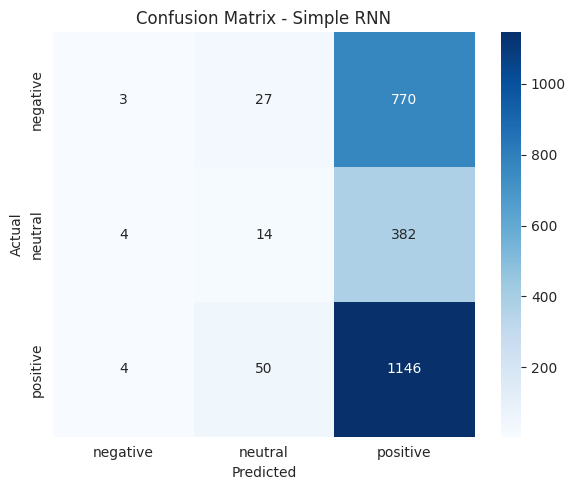

LSTM
Accuracy:          0.3337
Balanced Accuracy: 0.3400
Macro F1:          0.2008
              precision    recall  f1-score   support

    negative       0.34      0.96      0.50       800
     neutral       0.20      0.05      0.08       400
    positive       0.68      0.01      0.02      1200

    accuracy                           0.33      2400
   macro avg       0.41      0.34      0.20      2400
weighted avg       0.49      0.33      0.19      2400



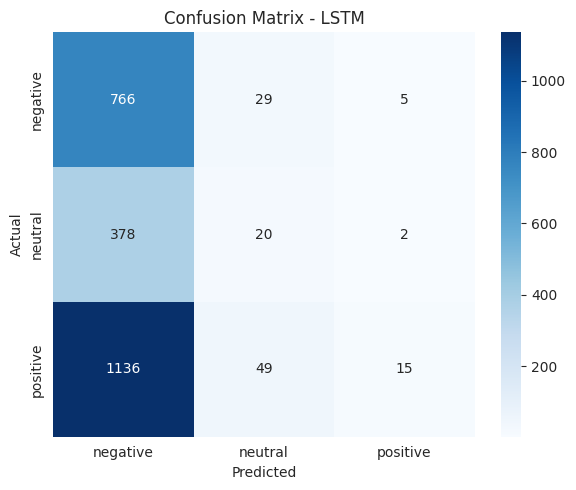

LSTM + Word2Vec
Accuracy:          0.7379
Balanced Accuracy: 0.6861
Macro F1:          0.6798
              precision    recall  f1-score   support

    negative       0.79      0.78      0.78       800
     neutral       0.38      0.48      0.43       400
    positive       0.87      0.80      0.83      1200

    accuracy                           0.74      2400
   macro avg       0.68      0.69      0.68      2400
weighted avg       0.76      0.74      0.75      2400



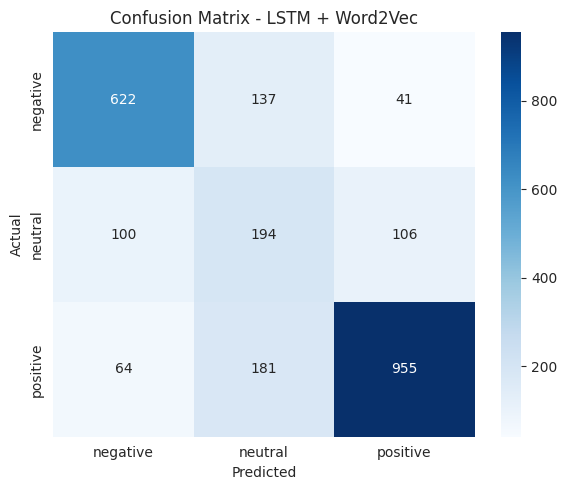

,model,accuracy,balanced_accuracy,macro_f1
2,LSTM + Word2Vec,0.737917,0.686111,0.679838
0,Simple RNN,0.484583,0.331250,0.239885
1,LSTM,0.333750,0.340000,0.200758


In [104]:
def evaluate_model(model, X_pad, y_true, name):
    prob = model.predict(X_pad, verbose=0)
    pred = np.argmax(prob, axis=1)

    acc = accuracy_score(y_true, pred)
    bal_acc = balanced_accuracy_score(y_true, pred)
    macro_f1 = f1_score(y_true, pred, average="macro")

    print("=" * 60)
    print(name)
    print(f"Accuracy:          {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"Macro F1:          {macro_f1:.4f}")
    print("=" * 60)
    print(classification_report(y_true, pred, target_names=label_enc.classes_))

    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_enc.classes_,
        yticklabels=label_enc.classes_
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1
    }

results = []
results.append(evaluate_model(model1, X_test_pad, y_test, "Simple RNN"))
results.append(evaluate_model(model2, X_test_pad, y_test, "LSTM"))
results.append(evaluate_model(model3, X_test_pad, y_test, "LSTM + Word2Vec"))

results_df = pd.DataFrame(results).sort_values(by="macro_f1", ascending=False)
results_df


## 16) Error analysis for the best model


In [105]:

best_model = model3

y_prob = best_model.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

actual_labels = label_enc.inverse_transform(y_test)
predicted_labels = label_enc.inverse_transform(y_pred)

error_df = pd.DataFrame({
    "text": X_test,
    "actual": actual_labels,
    "predicted": predicted_labels,
    "correct": actual_labels == predicted_labels
})

mistakes = error_df[~error_df["correct"]].reset_index(drop=True)
print(f"Misclassifications: {len(mistakes)} / {len(error_df)}")
print(f"Error rate: {len(mistakes) / len(error_df) * 100:.2f}%")

mistakes.head(5)


Misclassifications: 629 / 2400
Error rate: 26.21%


,text,actual,predicted,correct
0,ok book short sweet good short story lot sex l...,negative,neutral,False
1,warned either thing not no spoiler plot summar...,positive,negative,False
2,ok read thought book ok nothing really brag ma...,negative,neutral,False
3,story drug beginning quick ending read book th...,negative,neutral,False
4,disappointed far batting za maxfield's book wr...,neutral,negative,False


In [106]:

if len(mistakes) > 0:
    print("Sample mistakes:")
    for i, row in mistakes.head(3).iterrows():
        print("\n---")
        print("Text:", row["text"][:400])
        print("Actual:", row["actual"])
        print("Predicted:", row["predicted"])


Sample mistakes:

---
Text: ok book short sweet good short story lot sex like type book good read
Actual: negative
Predicted: neutral

---
Text: warned either thing not no spoiler plot summary recommendation included high level little book paranormal romance erotica series cougar fall feature variety shifter really one thing influence much enjoy book assuming generally enjoy genre first place would find eacute nage encounter one sexy lady three hot brother erotic question ask find curiosity piqued know would read not move something else re
Actual: positive
Predicted: negative

---
Text: ok read thought book ok nothing really brag main character stripper hoodlum not exactly type people would want read think romance novel aside not think character well developed struggle finish book
Actual: negative
Predicted: neutral



## 17) Save the best model and supporting files


In [107]:

model3.save("/content/lstm_word2vec_bookreviews.keras")

with open("/content/tokenizer_bookreviews.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("/content/label_encoder_bookreviews.pkl", "wb") as f:
    pickle.dump(label_enc, f)

print("Saved:")
print(" - /content/lstm_word2vec_bookreviews.keras")
print(" - /content/tokenizer_bookreviews.pkl")
print(" - /content/label_encoder_bookreviews.pkl")


Saved:
 - /content/lstm_word2vec_bookreviews.keras
 - /content/tokenizer_bookreviews.pkl
 - /content/label_encoder_bookreviews.pkl



## 18) Gradio prediction demo


In [108]:

!pip -q install gradio
import gradio as gr

EMOJI = {
    "positive": "📈 Positive",
    "neutral": "➡️ Neutral",
    "negative": "📉 Negative"
}

model_map = {
    "Simple RNN": model1,
    "LSTM": model2,
    "LSTM + Word2Vec": model3
}

def predict_sentiment(user_text, selected_model):
    if not str(user_text).strip():
        return "Please enter some text."

    cleaned = clean_text(user_text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

    model = model_map[selected_model]
    probs = model.predict(padded, verbose=0)[0]
    idx = int(np.argmax(probs))
    label = label_enc.inverse_transform([idx])[0]
    conf = float(probs[idx])

    details = []
    for i, cls in enumerate(label_enc.classes_):
        details.append(f"{cls}: {probs[i] * 100:.2f}%")

    return (
        f"Prediction: {EMOJI[label]}\n"
        f"Confidence: {conf * 100:.2f}%\n\n"
        "Class probabilities:\n" + "\n".join(details)
    )

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=[
        gr.Textbox(lines=6, placeholder="Paste a book review here..."),
        gr.Dropdown(
            choices=["Simple RNN", "LSTM", "LSTM + Word2Vec"],
            value="LSTM + Word2Vec",
            label="Choose model"
        )
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Book Review Sentiment Classifier",
    description="Predict sentiment from book reviews using RNN, LSTM, or LSTM + Word2Vec."
)

demo.launch(debug=False)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://506a548822528c4819.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
